import numpy as np
import torchaudio
from pathlib import Path
import matplotlib.pyplot as plt


def analyze_waveform_lengths(root, sr=16000):
    lengths = []
    paths = list(Path(root).rglob("*.wav"))

    for path in paths:
        try:
            waveform, file_sr = torchaudio.load(path)
            if file_sr != sr:
                resampler = torchaudio.transforms.Resample(file_sr, sr)
                waveform = resampler(waveform)
            lengths.append(waveform.shape[1])  # 長度以 sample 為單位
        except Exception as e:
            print(f"⚠️ Error reading {path}: {e}")

    return lengths


train_lengths = analyze_waveform_lengths("Data/Train/")
test_lengths = analyze_waveform_lengths("Data/Test/")
train_lengths_np = np.array(train_lengths)
print("Train Waveform analyze compelete")
test_lengths_np = np.array(test_lengths)
print("Test Waveform analyze compelete")

print("📊 Train Waveform 長度統計:")
print(f"最大值: {train_lengths_np.max()}")
print(f"最小值: {train_lengths_np.min()}")
print(f"平均值: {train_lengths_np.mean():.2f}")
print(f"中位數: {np.median(train_lengths_np)}")
print(f"90 百分位數: {np.percentile(train_lengths_np, 13)}")

print("📊 Test Waveform 長度統計:")
print(f"最大值: {test_lengths_np.max()}")
print(f"最小值: {test_lengths_np.min()}")
print(f"平均值: {test_lengths_np.mean():.2f}")
print(f"中位數: {np.median(test_lengths_np)}")
print(f"90 百分位數: {np.percentile(test_lengths_np, 30)}")

In [35]:

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
from pathlib import Path
import librosa
import numpy as np
from modelscope.pipelines import pipeline
from modelscope.models import Model
from modelscope.utils.constant import Tasks
import torchaudio
import random



class VoiceFolder(Dataset):
    def __init__(self, root, transform=None, sr=16000,target_len=58000):
        self.file_paths = []
        for path in  Path(root).rglob("*.wav"):
            w,_ = torchaudio.load(path)
            w = w.squeeze(0)
            cur_len = w.shape[-1]
            if cur_len > 35000:
                self.file_paths.append (path)
            #else:
                #print("Drop:",path)   
        self.transform = transform
        self.sr = sr
        self.target_len = target_len
        self.labels = sorted({p.parent.name for p in self.file_paths})
        self.label2id = {label: idx for idx, label in enumerate(self.labels)}

    def __len__(self):
        return len(self.file_paths)
    
    def pad_or_trim(self, waveform):
        cur_len = waveform.shape[-1]
        if cur_len >= self.target_len:
            start = cur_len - self.target_len
            start = random.randrange(start)
            return waveform[..., start:start + self.target_len]
        else:
            pad_len = self.target_len - cur_len
            return F.pad(waveform, (0, pad_len))
        #將音訊長度統整為target_len

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        try:
            waveform, file_sr = torchaudio.load(path)
            if file_sr != self.sr:
                resampler = torchaudio.transforms.Resample(orig_freq=file_sr, new_freq=self.sr)
                waveform = resampler(waveform)
            waveform = waveform.squeeze(0)
            if self.transform:
                waveform = self.transform(waveform)
            #設定預設transform
            waveform = waveform.float()
            max_val = waveform.abs().max()
            if max_val > 0:
                waveform = waveform / max_val
            waveform = self.pad_or_trim(waveform)
            label_str = path.parent.name
            label = self.label2id.get(label_str) 
            return waveform, label
        except Exception as e:
            print(f"[ERROR] loading {path}: {e}")
            return torch.zeros(self.sr), -1
        
def augment_waveform(waveform,sample_rate = 16000):#資料強化transform
    
    #隨機加入雜訊

    if random.randrange(4) == 0:
        noise = torch.randn_like(waveform) * 0.005  # 控制雜訊強度
        waveform = waveform + noise

    #隨機變更音高（±2個半音）
    if random.randrange(5) == 5:
        try:
            n_steps = random.uniform(-2.0, 2.0)
            waveform = waveform.numpy()
            waveform = librosa.effects.pitch_shift(y = waveform,sr = float(sample_rate), n_steps = float(n_steps))
            waveform = torch.from_numpy(waveform)
        except Exception as e:
            print(f"[WARN] pitch shift failed: {e}")
            waveform = torch.from_numpy(waveform)
    return waveform


train_root = "Data/Train/"
test_root = "Data/Test/"  
batch_size = 32
total_epoch = 100
lr = 1e-4
weight_decay=1e-4

train_dataset = VoiceFolder(root=train_root,transform = augment_waveform)
test_dataset = VoiceFolder(root=test_root)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

train_labels_set = set(train_dataset.labels)
test_labels_set = set(test_dataset.labels)
print(train_labels_set)
if train_labels_set != test_labels_set:
    print("⚠️ Train and test labels do not match!")
    print("Train labels only:", train_labels_set - test_labels_set)
    print("Test labels only :", test_labels_set - train_labels_set)
else:
    print("✅ Train and test labels match exactly.")


{'fear', 'neutral', 'sad', 'anger', 'happy', 'disgust'}
✅ Train and test labels match exactly.


In [36]:
import contextlib
import os
from collections import Counter
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")




# 從 train_dataset 中讀取有效的 label
all_labels = [label for _, label in train_dataset] 
# 計算 class weights
class_weight_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight = torch.tensor(class_weight_np, dtype=torch.float).to(device)

print("\n⚖️ Class weights:", class_weight)

feature_model = pipeline(
    task=Tasks.auto_speech_recognition, model='iic/emotion2vec_base')

num_classes = len(train_dataset.label2id)
print(num_classes, " type")
classifier = nn.Sequential(
    nn.BatchNorm1d(768),
    nn.Dropout(0.1),
    nn.Linear(768, 512),
    nn.GELU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.1),
    nn.Linear(512, 32),
    nn.GELU(),
    nn.BatchNorm1d(32),
    nn.Dropout(0.1),
    nn.Linear(32, num_classes)
).to(device)  # 768 是 Emotion2Vec 預設輸出維度
optimizer = torch.optim.Adam(classifier.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=3)

loss_fn = torch.nn.CrossEntropyLoss(weight = class_weight)


def train_epoch(epoch):
    classifier.train()
    train_loss = 0.
    correct_train = 0.
    total_train = 0.
    valid_labels = []
    count = 0
    for data in train_loader:
        waveforms, labels = data
        waveforms = waveforms.to(device)
        labels = labels.to(device)
        batch_feats = []
        temp = []
        with torch.no_grad():
            for waveform, label in zip(waveforms, labels):
                with open(os.devnull, 'w') as fnull:
                    with contextlib.redirect_stderr(fnull):
                        single_output = feature_model(
                            waveform)
                feats_np = single_output[0]['feats']  # 取出 list[0] 中的 'feats'
                feat_tensor = torch.from_numpy(feats_np).float()
                if torch.isnan(feat_tensor).any() or torch.isinf(feat_tensor).any():
                    # print("🚨 Detected NaN or Inf in features")
                    continue
                batch_feats.append(feat_tensor)
                temp.append(label)
        if len(batch_feats) < 2:
            continue
        features = torch.stack(batch_feats).to(
            device)  # shape: [batch_size, feat_dim]
        valid_labels += temp
        temp = torch.tensor(temp).to(device)
        outputs = classifier(features)
        loss = loss_fn(outputs, temp)
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == temp).sum().item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        total_train += temp.size(0)
        # print("epoch ",epoch," trainloop ",count," finish")
        #count += 1
        #if count > 50:
            #break

    train_loss /= len(valid_labels)
    train_accuracy = correct_train / total_train

    return train_loss, train_accuracy*100


def validation(epoch):
    classifier.eval()
    correct = 0.
    total = 0.
    val_loss = 0.
    valid_labels = []
    count = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in val_loader:
            waveforms, labels = data
            waveforms = waveforms.to(device)
            labels = labels.to(device)
            batch_feats = []
            temp = []
            # waveforms shape: [batch_size, ...]
            for waveform, label in zip(waveforms, labels):
                with open(os.devnull, 'w') as fnull:
                    with contextlib.redirect_stderr(fnull):
                        single_output = feature_model(
                            waveform)  # 加 batch 維度
                feats_np = single_output[0]['feats']  # 取出 list[0] 中的 'feats'
                feat_tensor = torch.from_numpy(feats_np).float()
                if torch.isnan(feat_tensor).any() or torch.isinf(feat_tensor).any():
                    # print("🚨 Detected NaN or Inf in features")
                    continue
                batch_feats.append(feat_tensor)
                temp.append(label)
            if len(batch_feats) < 2:
                continue
            features = torch.stack(batch_feats).to(
                device)  # shape: [batch_size, feat_dim]
            valid_labels += temp
            temp = torch.tensor(temp).to(device)
            outputs = classifier(features)
            loss = loss_fn(outputs, temp)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(temp.cpu().numpy())

            correct += (preds == temp).sum().item()
            total += temp.size(0)
            # print("epoch ",epoch," testloop ",count," finish")
            #count += 1
            #if count > 50:
                #break

    val_loss /= len(valid_labels)
    val_accuracy = correct / total
    return val_loss, val_accuracy*100, all_preds, all_labels

Using cuda device

⚖️ Class weights: tensor([1.0072, 0.7916, 1.0924, 1.1708, 1.2799, 0.8382], device='cuda:0')


2025-06-14 14:16:29,313 - modelscope - WARNING - Model revision not specified, use revision: v2.0.4


2025-06-14 14:16:30,755 - modelscope - WARNING - Model revision not specified, use revision: v2.0.4
2025-06-14 14:16:31,005 - modelscope - INFO - initiate model from C:\Users\ChiaYan\.cache\modelscope\hub\models\iic\emotion2vec_base
2025-06-14 14:16:31,006 - modelscope - INFO - initiate model from location C:\Users\ChiaYan\.cache\modelscope\hub\models\iic\emotion2vec_base.
2025-06-14 14:16:31,009 - modelscope - INFO - initialize model from C:\Users\ChiaYan\.cache\modelscope\hub\models\iic\emotion2vec_base


funasr version: 1.2.6.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel
You are using the latest version of funasr-1.2.6


2025-06-14 14:16:33,141 - modelscope - WARNING - No preprocessor field found in cfg.
2025-06-14 14:16:33,142 - modelscope - WARNING - No val key and type key found in preprocessor domain of configuration.json file.
2025-06-14 14:16:33,142 - modelscope - WARNING - Cannot find available config to build preprocessor at mode inference, current config: {'model_dir': 'C:\\Users\\ChiaYan\\.cache\\modelscope\\hub\\models\\iic\\emotion2vec_base'}. trying to build by task and model information.
2025-06-14 14:16:33,143 - modelscope - WARNING - No preprocessor key ('funasr', 'emotion-recognition') found in PREPROCESSOR_MAP, skip building preprocessor.


6  type


In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

import pandas as pd


best_val_acc = 0
patience = 5
wait = 0

train_loss = []
train_acc = []
val_loss = []
val_acc = []
print("start")

for epoch in range(total_epoch):
    tl, ta = train_epoch(epoch+1)
    vl, va, all_preds, all_labels = validation(epoch+1)
    train_loss.append(tl)
    train_acc.append(ta)
    val_loss.append(vl)
    val_acc.append(va)
    scheduler.step(vl)

    print(f"Epoch {epoch+1}  Train Loss: {train_loss[epoch]:.4f}  Train Accuracy: {train_acc[epoch]:.2f}% \
        Val Loss: {val_loss[epoch]:.4f}  Val Accuracy: {val_acc[epoch]:.2f}% ")
    cm = confusion_matrix(all_labels, all_preds)
    df_cm = pd.DataFrame(cm, index=list(train_labels_set), columns=list(train_labels_set))
    print(df_cm)

    if va > best_val_acc:
        best_val_acc = va
        wait = 0
    else:
        wait += 1
    if wait > patience:
        break

start
Epoch 1  Train Loss: 0.0408  Train Accuracy: 50.63%         Val Loss: 0.0319  Val Accuracy: 65.20% 
         fear  neutral  sad  anger  happy  disgust
fear     1535       61   56    122    115       80
neutral   241     1524  144    108    182      363
sad       147       83  975    143    146      311
anger     223       67  169    930    227       90
happy      61       17   21     58   1355       76
disgust   115      189  172     73    326     1523
Epoch 2  Train Loss: 0.0324  Train Accuracy: 62.09%         Val Loss: 0.0273  Val Accuracy: 69.23% 
         fear  neutral   sad  anger  happy  disgust
fear     1591       62    77    135     55       49
neutral   233     1631   203    106     83      306
sad       104       58  1216    136     82      209
anger     214       60   181   1093    107       51
happy      56        8    39    121   1293       71
disgust    68      167   330     95    235     1503
Epoch 3  Train Loss: 0.0294  Train Accuracy: 65.02%         Val Loss: 0.0

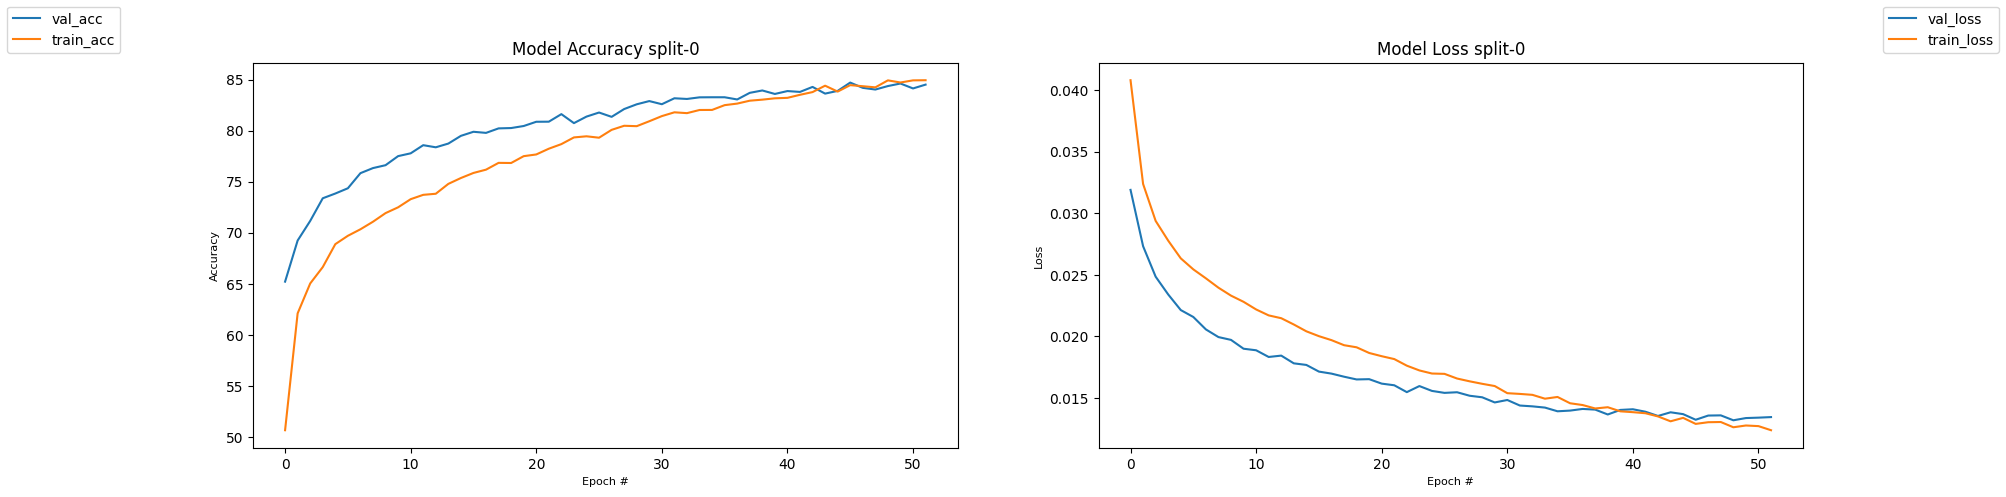

In [38]:
import matplotlib.pyplot as plt
import matplotlib as mpl
loss_plot = [val_loss, train_loss]
acc_plot = [val_acc, train_acc]


def draw(acc_plot, loss_plot, hist_lr=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
    for line in acc_plot:
        ax1.plot(range(len(line)), line)
    ax1.set_xlabel("Epoch #", fontsize=8)
    ax1.set_ylabel("Accuracy", fontsize=8)
    ax1.set_title("Model Accuracy split-0")
    for line in loss_plot:
        ax2.plot(range(len(line)), line)
    ax2.set_xlabel("Epoch #", fontsize=8)
    ax2.set_ylabel("Loss", fontsize=8)
    ax2.set_title("Model Loss split-0")
    labels1 = ["val_acc", "train_acc"]
    labels2 = ["val_loss", "train_loss"]
    fig.legend(labels1, loc="upper left")
    fig.legend(labels2, loc="upper right")


draw(acc_plot, loss_plot)